In [20]:
%pip install numpy opencv-python
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     ------------------- ------------------ 41.0/80.3 kB 991.0 kB/s eta 0:00:01
     ---------------------------------------- 80.3/80.3 kB 1.1 MB/s eta 0:00:00
     ---------------------------------------- 0.0/127.4 kB ? eta -:--:--
     ---------------------------- ---------- 92.2/127.4 kB 2.6 MB/s eta 0:00:01
     -------------------------------------- 127.4/127.4 kB 1.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
    --------------------------------------- 0.2/9.3 MB 6.9 MB/s eta 0:00:02
   -- ------------------------------------- 0.7/9.3 MB 8.5 MB/s eta 0:00:02
   ------ --------------------------------- 1.5/9.3 MB 10.5 MB/s eta 0:00:01
   ------------ --------------------------- 2.8/9.3 MB 14.9 MB/s eta 0:00:01
   ------------------- -------------------- 4.6/9.3 MB 21.2 MB/s eta 0:00:01
   --------


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

print("NumPy:", np.__version__)
print("OpenCV:", cv2.__version__)

NumPy: 2.4.6
OpenCV: 5.0.0


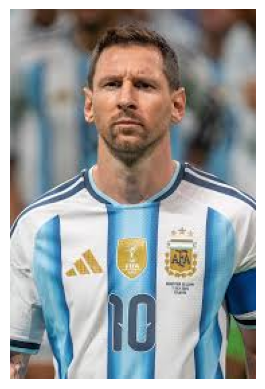

In [22]:
imagen = cv2.imread("images.jpg")

if imagen is None:
    print("No se encontró la imagen. Revisa el nombre y la ruta.")
else:
    # OpenCV lee en BGR; convertimos a RGB para mostrar los colores.
    plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

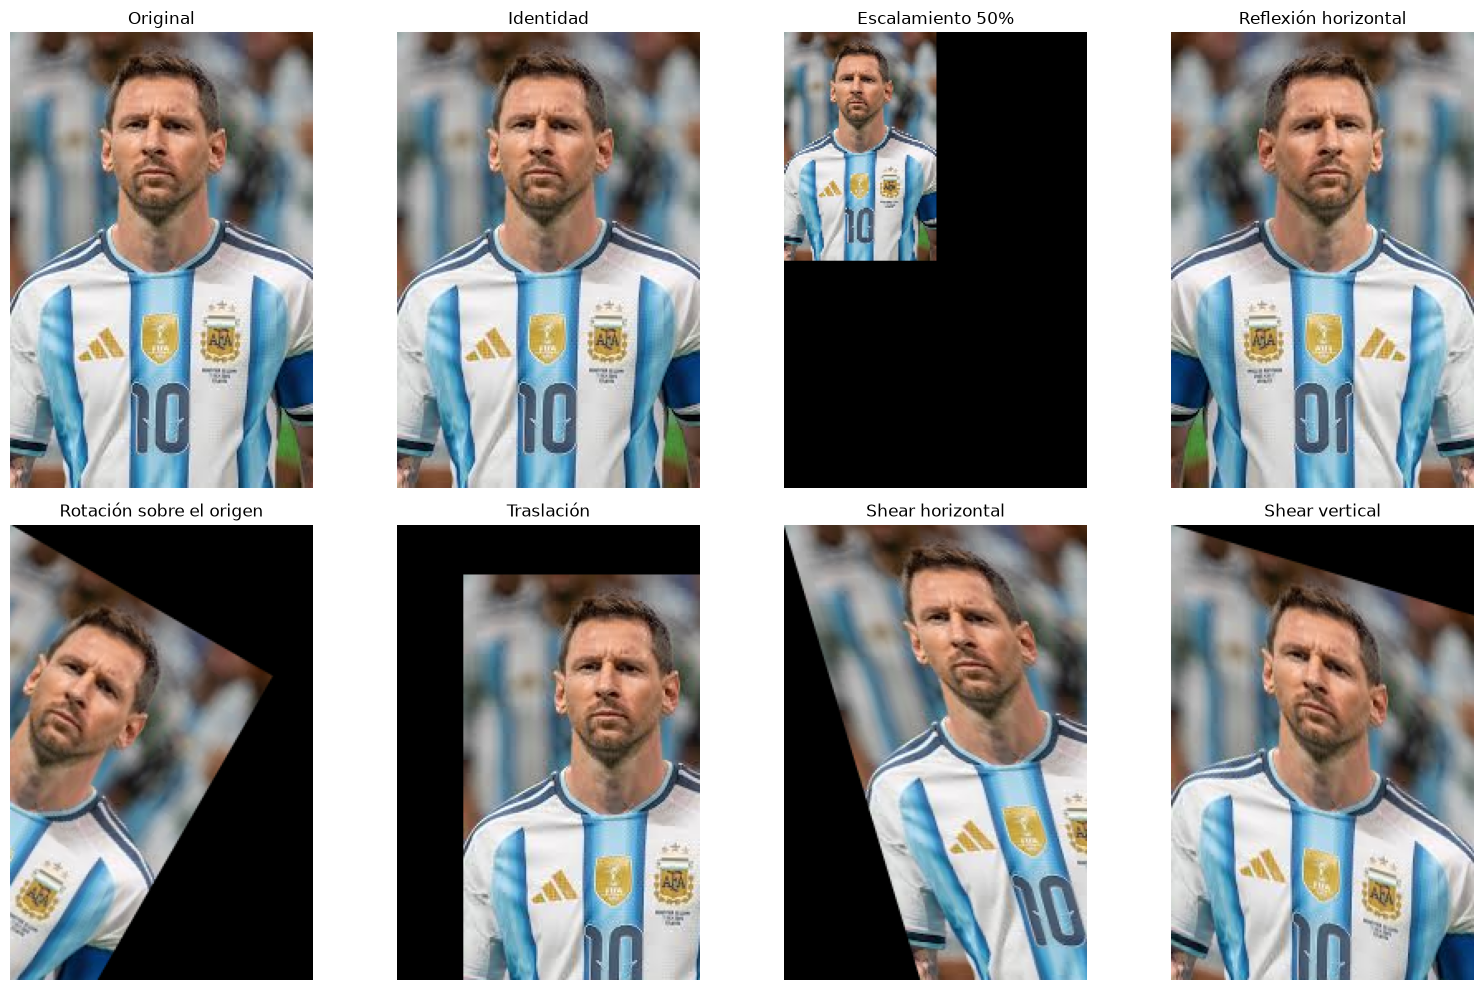

In [25]:

alto, ancho = imagen.shape[:2]
theta = np.deg2rad(30)

matrices = {
    "Identidad": np.float32([
        [1, 0, 0],
        [0, 1, 0]
    ]),
    "Escalamiento 50%": np.float32([
        [0.5, 0, 0],
        [0, 0.5, 0]
    ]),
    "Reflexión horizontal": np.float32([
        [-1, 0, ancho - 1],
        [0, 1, 0]
    ]),
    "Rotación sobre el origen": np.float32([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0]
    ]),
    "Traslación": np.float32([
        [1, 0, 40],
        [0, 1, 30]
    ]),
    "Shear horizontal": np.float32([
        [1, 0.3, 0],
        [0, 1, 0]
    ]),
    "Shear vertical": np.float32([
        [1, 0, 0],
        [0.3, 1, 0]
    ])
}

resultados = {}
fig, ejes = plt.subplots(2, 4, figsize=(16, 10))
ejes = ejes.ravel()

ejes[0].imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
ejes[0].set_title("Original")
ejes[0].axis("off")

for eje, (nombre, matriz) in zip(ejes[1:], matrices.items()):
    resultado = cv2.warpAffine(imagen, matriz, (ancho, alto))
    resultados[nombre] = resultado

    eje.imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
    eje.set_title(nombre)
    eje.axis("off")

plt.tight_layout()
plt.show()